In [3]:
# Establishes fixed reference points
from pathlib import Path
from typing import List, Tuple, Dict
import importlib
import shutil
import random

import prepare_dog_dataset
importlib.reload(prepare_dog_dataset)
from prepare_dog_dataset import prepare_dog_only_data

PROJECT_ROOT = Path(".").resolve()
RAW_SOURCE_DIR = PROJECT_ROOT / "raw_data"
FILTERED_DATA_DIR = PROJECT_ROOT / "filtered_raw_data"
RAW_DATA_DIR = FILTERED_DATA_DIR
PROCESSED_DATA_DIR = PROJECT_ROOT / "dataset"
CONFIG_FILE = PROJECT_ROOT / "configs" / "data.yaml"

In [4]:
# Filters cat annotations from the added dataset and normalizes all dog labels to class 0
filter_summary = prepare_dog_only_data(RAW_SOURCE_DIR, FILTERED_DATA_DIR)
print("Dog-only filtering summary:", filter_summary)

Dog-only filtering summary: {'copied_images': 1526, 'skipped_images': 1, 'skipped_missing_labels': 34, 'dog_instances': 1971}


In [5]:
# Scans the raw data folder for image-label pairs and validates them
def collect_and_validate_pairs(raw_dir: Path) -> List[Tuple[Path, Path]]:


    if not raw_dir.is_dir():
        raise FileNotFoundError(f"Raw data directory does not exist: {raw_dir}")

    image_suffixes = {".jpg", ".jpeg", ".png"}
    pairs = []
    expected_labels = set()

    for image_path in sorted(raw_dir.rglob("*")):
        if not image_path.is_file() or image_path.suffix.lower() not in image_suffixes:
            continue

        labels_dir = image_path.parent.parent / "labels"
        label_path = labels_dir / f"{image_path.stem}.txt"

        if not label_path.is_file():
            raise FileNotFoundError(
                f"Missing label for image '{image_path}': expected '{label_path}'"
            )

        pairs.append((image_path, label_path))
        expected_labels.add(label_path.resolve())

    for label_path in raw_dir.rglob("labels/*.txt"):
        if label_path.resolve() not in expected_labels:
            raise ValueError(f"Label has no matching image: {label_path}")

    if not pairs:
        raise ValueError(f"No valid image-label pairs found in {raw_dir}")

    return pairs

In [6]:
# Splits the raw data into train/valid/test and creates the dataset directories
def split_and_distribute(
    pairs: List[Tuple[Path, Path]],
    output_dir: Path,
    train_ratio: float = 0.70,
    val_ratio: float = 0.20,
    test_ratio: float = 0.10,
    seed: int = 42
) -> Dict[str, int]:
  
    if not pairs:
        raise ValueError("No image-label pairs provided")

    ratios = (train_ratio, val_ratio, test_ratio)
    if any(ratio < 0 for ratio in ratios) or not abs(sum(ratios) - 1.0) < 1e-9:
        raise ValueError("Split ratios must be non-negative and sum to 1")

    if output_dir.exists():
        shutil.rmtree(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    shuffled_pairs = list(pairs)
    random.Random(seed).shuffle(shuffled_pairs)

    train_end = int(len(shuffled_pairs) * train_ratio)
    val_end = train_end + int(len(shuffled_pairs) * val_ratio)
    splits = {
        "train": shuffled_pairs[:train_end],
        "valid": shuffled_pairs[train_end:val_end],
        "test": shuffled_pairs[val_end:],
    }

    for split_name, split_pairs in splits.items():
        images_dir = output_dir / split_name / "images"
        labels_dir = output_dir / split_name / "labels"
        images_dir.mkdir(parents=True, exist_ok=True)
        labels_dir.mkdir(parents=True, exist_ok=True)

        for image_path, label_path in split_pairs:
            shutil.copy2(image_path, images_dir / image_path.name)
            shutil.copy2(label_path, labels_dir / label_path.name)

    return {split_name: len(split_pairs) for split_name, split_pairs in splits.items()}

In [7]:
# Generates data.yaml file for YOLO training
def write_dataset_yaml(output_path: Path, dataset_root: Path) -> None:
  
    dataset_root = dataset_root.resolve()
    output_path.parent.mkdir(parents=True, exist_ok=True)
    output_path.write_text(
        "\n".join([
            f"path: {dataset_root.as_posix()}",
            "train: train/images",
            "val: valid/images",
            "test: test/images",
            "nc: 1",
            "names: ['dog']",
            "",
        ]),
        encoding="utf-8",
    )

# Final check of the splits to ensure there are no overlaps, all images have labels, and YOLO label values are valid
def audit_final_splits(dataset_dir: Path) -> None:
    
    image_suffixes = {".jpg", ".jpeg", ".png"}
    split_names = ("train", "valid", "test")
    filenames_by_split = {}
    total_images = 0
    total_instances = 0

    for split_name in split_names:
        images_dir = dataset_dir / split_name / "images"
        labels_dir = dataset_dir / split_name / "labels"

        if not images_dir.is_dir() or not labels_dir.is_dir():
            raise FileNotFoundError(
                f"Missing images or labels directory for split '{split_name}'"
            )

        image_paths = sorted(
            path for path in images_dir.iterdir()
            if path.is_file() and path.suffix.lower() in image_suffixes
        )
        filenames_by_split[split_name] = {path.name for path in image_paths}
        total_images += len(image_paths)

        for image_path in image_paths:
            label_path = labels_dir / f"{image_path.stem}.txt"
            if not label_path.is_file():
                raise FileNotFoundError(f"Missing label for image: {image_path}")

        for label_path in labels_dir.glob("*.txt"):
            for line_number, line in enumerate(
                label_path.read_text(encoding="utf-8").splitlines(), start=1
            ):
                fields = line.split()
                if not fields:
                    continue
                if len(fields) != 5 or fields[0] != "0":
                    raise ValueError(
                        f"Invalid YOLO row in {label_path}, line {line_number}"
                    )
                try:
                    values = [float(value) for value in fields[1:]]
                except ValueError as error:
                    raise ValueError(
                        f"Non-numeric YOLO values in {label_path}, line {line_number}"
                    ) from error
                if not all(-1e-4 <= value <= 1.0 + 1e-4 for value in values):
                    raise ValueError(
                        f"Out-of-range YOLO values in {label_path}, line {line_number}"
                    )
                total_instances += 1

    for first_index, first_split in enumerate(split_names):
        for second_split in split_names[first_index + 1:]:
            overlap = filenames_by_split[first_split] & filenames_by_split[second_split]
            if overlap:
                raise ValueError(
                    f"Filename overlap between {first_split} and {second_split}: "
                    f"{sorted(overlap)}"
                )

    print(f"Total images: {total_images}")
    print(f"Total dog instances: {total_instances}")

In [8]:
# Executes the functions in cells 2-4 
pairs = collect_and_validate_pairs(RAW_DATA_DIR)
counts = split_and_distribute(pairs, PROCESSED_DATA_DIR)
write_dataset_yaml(CONFIG_FILE, PROCESSED_DATA_DIR)
audit_final_splits(PROCESSED_DATA_DIR)

print("Split counts:", counts)

Total images: 1526
Total dog instances: 1971
Split counts: {'train': 1068, 'valid': 305, 'test': 153}


In [10]:
# Loads the YOLO model and trains it on the dataset
from ultralytics import YOLO


def train_detector(
    model_name: str,
    data_yaml: Path,
    epochs: int = 75,
    imgsz: int = 640,
    batch: int = 16,
    box: float = 8.5,
    cls: float = 0.7,
    dfl: float = 1.8,
    project_name: str = "runs"
) -> YOLO:
    """
    Trains a single-class YOLO detector with localization-focused loss weights.
    """
    if epochs <= 0 or imgsz <= 0 or batch == 0:
        raise ValueError("epochs and imgsz must be positive; batch must be non-zero")
    if not data_yaml.is_file():
        raise FileNotFoundError(f"Dataset YAML does not exist: {data_yaml}")
    if box <= 0 or cls <= 0 or dfl <= 0:
        raise ValueError("box, cls, and dfl loss weights must be positive")

    project_path = Path(project_name)
    if not project_path.is_absolute():
        project_path = PROJECT_ROOT / project_path

    model = YOLO(model_name)
    model.train(
        data=str(data_yaml.resolve()),
        epochs=epochs,
        imgsz=imgsz,
        batch=batch,
        box=box,
        cls=cls,
        dfl=dfl,
        project=str(project_path.resolve()),
        name=Path(model_name).stem,
        workers=0,
        device=0,
        exist_ok=True,
    )
    return model

In [11]:
# Evaluates the trained YOLO model on the specified dataset split
def evaluate_model(
    model_weights: Path,
    data_yaml: Path,
    split: str = "test",
    project_name: str = "runs/eval"
) -> Dict[str, float]:
   
    if not model_weights.is_file():
        raise FileNotFoundError(f"Model weights do not exist: {model_weights}")
    if not data_yaml.is_file():
        raise FileNotFoundError(f"Dataset YAML does not exist: {data_yaml}")
    if split not in {"train", "val", "test"}:
        raise ValueError("split must be one of: train, val, test")

    model = YOLO(str(model_weights))
    validation = model.val(
        data=str(data_yaml.resolve()),
        split=split,
        project=project_name,
        name=Path(model_weights).stem,
        exist_ok=True,
    )
    box_metrics = validation.box
    precision_value = box_metrics.mp
    recall_value = box_metrics.mr
    precision = float(precision_value() if callable(precision_value) else precision_value)
    recall = float(recall_value() if callable(recall_value) else recall_value)
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0

    return {
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "map50": float(box_metrics.map50),
        "map50_95": float(box_metrics.map),
    }

In [12]:
# Measures operational inference speed and prints the side-by-side comparison table required for the Bonus Task.
def benchmark_latency(
    model_weights: Path,
    sample_images_dir: Path,
    device: str = "cuda"
) -> Dict[str, float]:
    
    if not model_weights.is_file():
        raise FileNotFoundError(f"Model weights do not exist: {model_weights}")
    if not sample_images_dir.is_dir():
        raise FileNotFoundError(f"Image directory does not exist: {sample_images_dir}")

    image_suffixes = {".jpg", ".jpeg", ".png"}
    image_paths = sorted(
        path for path in sample_images_dir.iterdir()
        if path.is_file() and path.suffix.lower() in image_suffixes
    )
    if not image_paths:
        raise ValueError(f"No supported images found in {sample_images_dir}")

    import torch
    if device == "cuda" and not torch.cuda.is_available():
        device = "cpu"

    model = YOLO(str(model_weights))
    results = model.predict(
        source=[str(path) for path in image_paths],
        device=device,
        verbose=False,
        stream=False,
    )
    speed_keys = ("preprocess", "inference", "postprocess")
    averages = {
        key: sum(float(result.speed.get(key, 0.0)) for result in results) / len(results)
        for key in speed_keys
    }
    total_latency = sum(averages.values())
    return {
        "preprocess_ms": averages["preprocess"],
        "inference_ms": averages["inference"],
        "postprocess_ms": averages["postprocess"],
        "total_latency_ms": total_latency,
        "fps": 1000.0 / total_latency if total_latency else 0.0,
    }


def compare_models(
    nano_metrics: Dict[str, float],
    small_metrics: Dict[str, float],
    nano_weights: Path,
    small_weights: Path
) -> None:
  
    for weights in (nano_weights, small_weights):
        if not weights.is_file():
            raise FileNotFoundError(f"Model weights do not exist: {weights}")

    def row(label: str, metrics: Dict[str, float], weights: Path) -> None:
        size_mb = weights.stat().st_size / (1024 * 1024)
        print(
            f"{label:>6} | precision={metrics.get('precision', 0.0):.4f} "
            f"recall={metrics.get('recall', 0.0):.4f} "
            f"f1={metrics.get('f1', 0.0):.4f} "
            f"mAP50={metrics.get('map50', 0.0):.4f} "
            f"mAP50-95={metrics.get('map50_95', 0.0):.4f} "
            f"size_mb={size_mb:.2f} "
            f"latency_ms={metrics.get('total_latency_ms', 0.0):.2f} "
            f"fps={metrics.get('fps', 0.0):.2f}"
        )

    print("Model  | quality metrics                         | runtime")
    row("nano", nano_metrics, nano_weights)
    row("small", small_metrics, small_weights)
    print("The nano model prioritizes smaller files and faster throughput; the small model typically trades extra compute for higher accuracy.")

In [13]:
# Runs the final model on brand-new, real-world images that were completely outside the dataset
def run_unseen_inferences(
    model_weights: Path,
    source_dir: Path,
    output_dir: Path,
    conf_thresh: float = 0.25
) -> None:
    
    if not model_weights.is_file():
        raise FileNotFoundError(f"Model weights do not exist: {model_weights}")
    if not source_dir.is_dir():
        raise FileNotFoundError(f"Source directory does not exist: {source_dir}")
    if not 0.0 <= conf_thresh <= 1.0:
        raise ValueError("conf_thresh must be between 0 and 1")

    image_suffixes = {".jpg", ".jpeg", ".png"}
    image_paths = sorted(
        path for path in source_dir.iterdir()
        if path.is_file() and path.suffix.lower() in image_suffixes
    )
    if len(image_paths) < 5:
        raise ValueError(
            f"At least 5 unseen images are required; found {len(image_paths)}"
        )

    output_dir.mkdir(parents=True, exist_ok=True)
    model = YOLO(str(model_weights))
    model.predict(
        source=[str(path) for path in image_paths],
        conf=conf_thresh,
        save=True,
        save_conf=True,
        project=str(output_dir.resolve()),
        name="predictions",
        exist_ok=True,
        verbose=False,
    )
    print(f"Saved annotated predictions for {len(image_paths)} images to {output_dir / 'predictions'}")

In [14]:
# 1. Train YOLO11n (Baseline)
print("=== Starting Training: YOLO11n ===")
model_nano = train_detector(
    model_name="yolo11n.pt",
    data_yaml=CONFIG_FILE,
    epochs=75,
    imgsz=640,
    batch=16,
    box=8.5,
    cls=0.7,
    dfl=1.8,
    project_name="runs"
)

# 2. Train YOLO11s (Bonus Model Comparison)
print("\n=== Starting Training: YOLO11s (Bonus Variant) ===")
model_small = train_detector(
    model_name="yolo11s.pt",
    data_yaml=CONFIG_FILE,
    epochs=75,
    imgsz=640,
    batch=8,
    box=8.5,
    cls=0.7,
    dfl=1.8,
    project_name="runs"
)

=== Starting Training: YOLO11n ===
New https://pypi.org/project/ultralytics/8.4.174 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.171  Python-3.13.5 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 6144MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=8.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.7, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=D:\Code\dog_detection_project\configs\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.8, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=75, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.0

In [15]:
def find_model_weights(model_name: str) -> Path:
    """Find checkpoints from the current flat layout or the previous nested layout."""
    candidates = (
        PROJECT_ROOT / "runs" / model_name / "weights" / "best.pt",
        PROJECT_ROOT / "runs" / "detect" / "runs" / model_name / "weights" / "best.pt",
    )
    for weights_path in candidates:
        if weights_path.is_file():
            return weights_path
    raise FileNotFoundError(
        f"No checkpoint found for {model_name}. Checked: "
        + ", ".join(str(path) for path in candidates)
    )


NANO_WEIGHTS = find_model_weights("yolo11n")
SMALL_WEIGHTS = find_model_weights("yolo11s")

print("Evaluating YOLO11n on reserved test set...")
nano_eval = evaluate_model(NANO_WEIGHTS, CONFIG_FILE, split="test", project_name="runs/eval")

print("Evaluating YOLO11s on reserved test set...")
small_eval = evaluate_model(SMALL_WEIGHTS, CONFIG_FILE, split="test", project_name="runs/eval")

Evaluating YOLO11n on reserved test set...
Ultralytics 8.4.171  Python-3.13.5 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 6144MiB)
YOLO11n summary (fused): 100 layers, 2,582,347 parameters, 0 gradients, 6.4 GFLOPs
WARNING val: Slow image access detected (ping: 0.20.1 ms, read: 49.843.2 MB/s, size: 137.8 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips
val: Scanning D:\Code\dog_detection_project\dataset\test\labels... 153 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 153/153 1.7Kit/s 0.1s
val: New cache created: D:\Code\dog_detection_project\dataset\test\labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 2.1s/it 21.4s.2s1
                   all        153        204      0.952      0.799      0.885      0.686
Speed: 2.4ms preprocess, 6.4ms inference, 0.0ms loss, 1.1ms postprocess per image
Res

In [16]:
TEST_IMAGES_DIR = PROCESSED_DATA_DIR / "test" / "images"

print("Profiling YOLO11n throughput...")
nano_latency = benchmark_latency(NANO_WEIGHTS, TEST_IMAGES_DIR, device="cuda")

print("Profiling YOLO11s throughput...")
small_latency = benchmark_latency(SMALL_WEIGHTS, TEST_IMAGES_DIR, device="cuda")

# Merge metric dictionaries for unified reporting
nano_full_metrics = {**nano_eval, **nano_latency}
small_full_metrics = {**small_eval, **small_latency}

print("\n" + "="*80)
print("ARL PERCEPTION WORKSHOP - BONUS MODEL COMPARISON REPORT")
print("="*80)
compare_models(nano_full_metrics, small_full_metrics, NANO_WEIGHTS, SMALL_WEIGHTS)

Profiling YOLO11n throughput...
Profiling YOLO11s throughput...

ARL PERCEPTION WORKSHOP - BONUS MODEL COMPARISON REPORT
Model  | quality metrics                         | runtime
  nano | precision=0.9519 recall=0.7990 f1=0.8688 mAP50=0.8854 mAP50-95=0.6856 size_mb=5.21 latency_ms=15.05 fps=66.44
 small | precision=0.9198 recall=0.7869 f1=0.8482 mAP50=0.8780 mAP50-95=0.6894 size_mb=18.27 latency_ms=88.36 fps=11.32
The nano model prioritizes smaller files and faster throughput; the small model typically trades extra compute for higher accuracy.


In [17]:
UNSEEN_DIR = PROJECT_ROOT / "unseen_test_images"
INFERENCE_OUTPUT_DIR = PROJECT_ROOT / "runs" / "unseen_eval"

# Ensure at least 5 unseen test images exist in the folder before running
run_unseen_inferences(
    model_weights=NANO_WEIGHTS,
    source_dir=UNSEEN_DIR,
    output_dir=INFERENCE_OUTPUT_DIR,
    conf_thresh=0.30
)

Results saved to D:\Code\dog_detection_project\runs\unseen_eval\predictions
Saved annotated predictions for 9 images to D:\Code\dog_detection_project\runs\unseen_eval\predictions


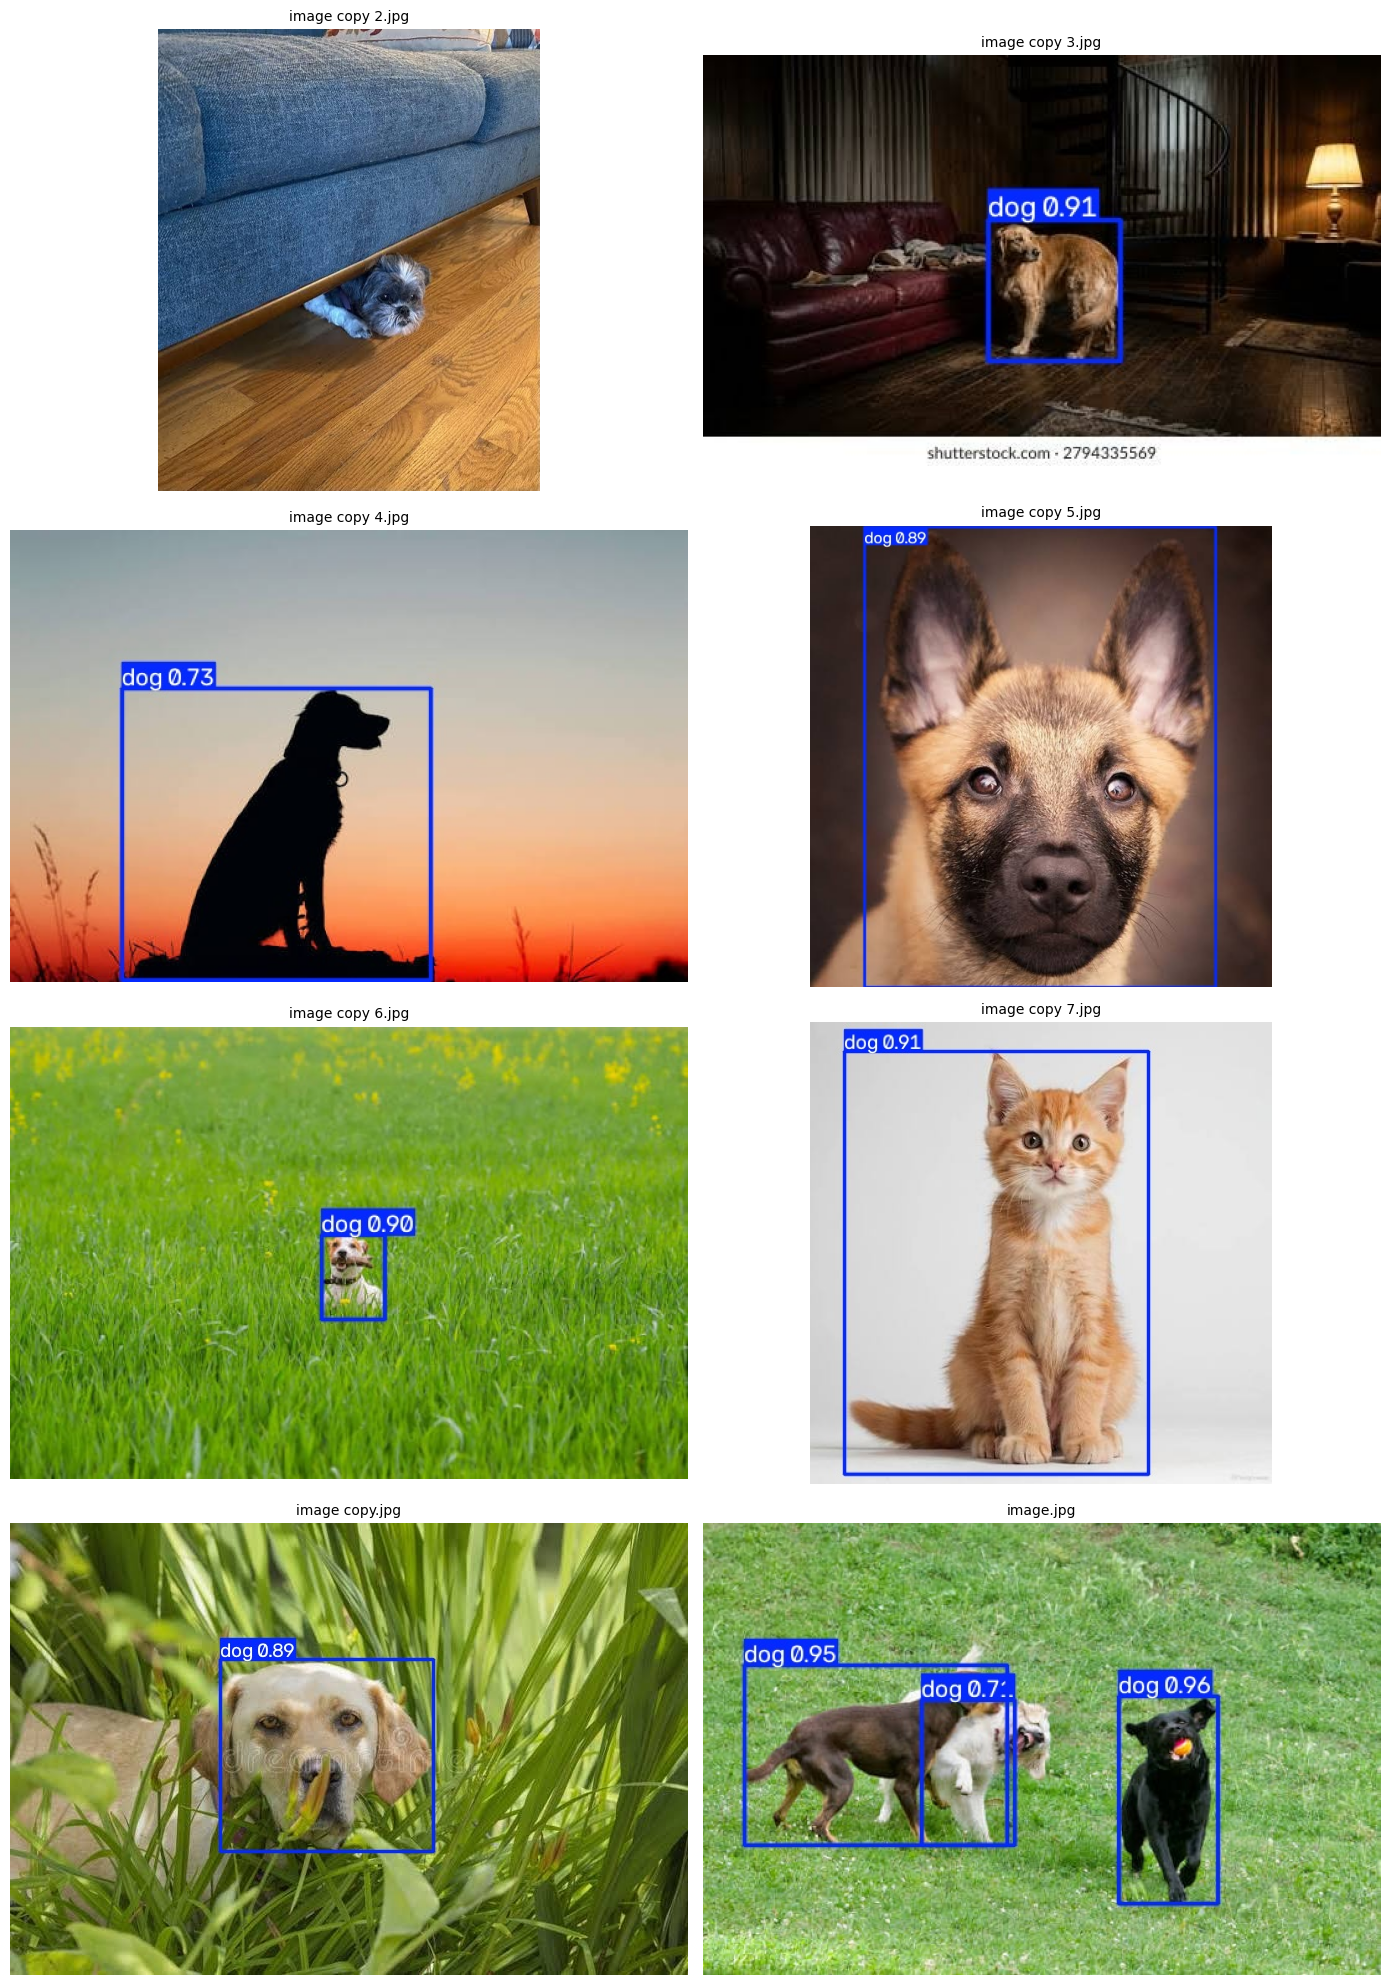

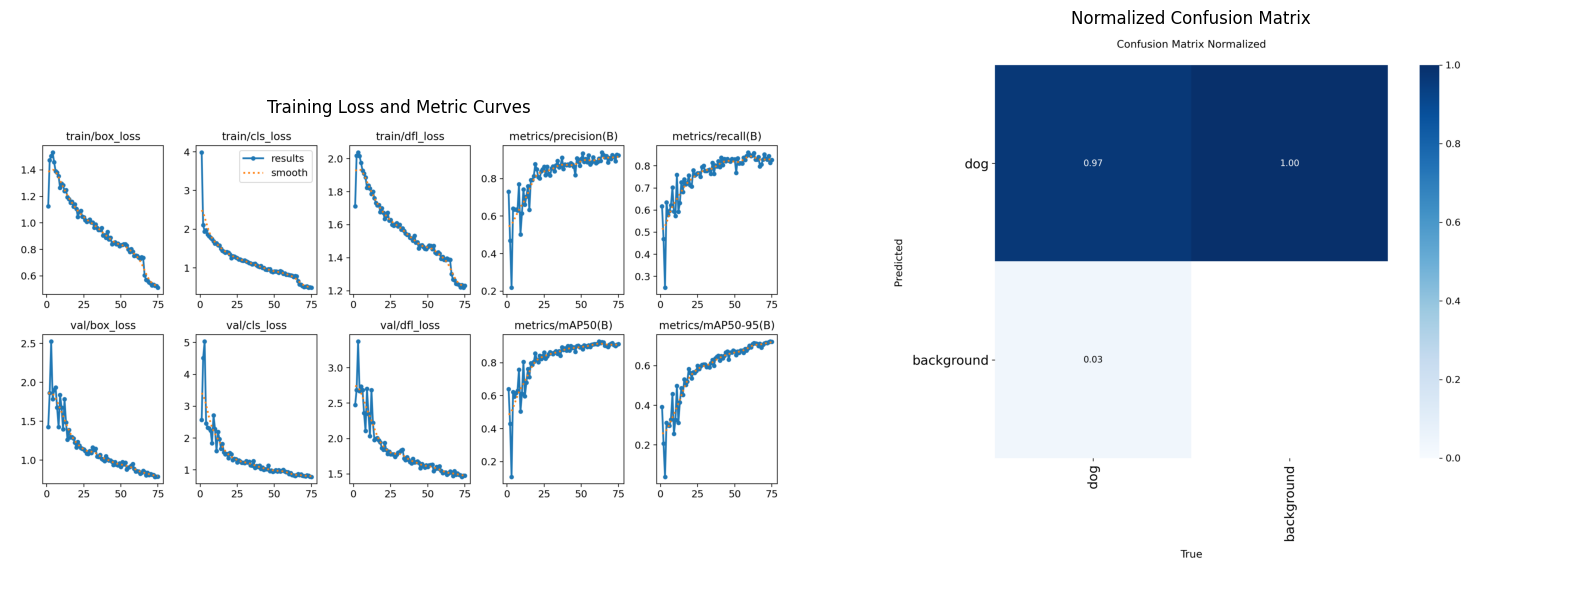

In [18]:
import matplotlib.image as mpimg
import matplotlib.pyplot as plt


def display_results(results_dir: Path, max_images: int = 8) -> None:
    """Display saved prediction images inline in the notebook."""
    pred_dir = results_dir / "predictions"
    if not pred_dir.is_dir():
        print(f"No prediction directory found: {pred_dir}")
        return

    image_suffixes = {".jpg", ".jpeg", ".png"}
    images = sorted(
        path for path in pred_dir.iterdir()
        if path.is_file() and path.suffix.lower() in image_suffixes
    )[:max_images]
    if not images:
        print("No prediction images found to display.")
        return

    cols = 2
    rows = (len(images) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(14, 5 * rows))
    axes = [axes] if len(images) == 1 else axes.flatten()

    for ax, image_path in zip(axes, images):
        ax.imshow(mpimg.imread(str(image_path)))
        ax.set_title(image_path.name, fontsize=10)
        ax.axis("off")

    for ax in axes[len(images):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


def display_training_artifacts(train_run_dir: Path) -> None:
    """Display YOLO training curves and the normalized confusion matrix inline."""
    plot_paths = [
        (train_run_dir / "results.png", "Training Loss and Metric Curves"),
        (train_run_dir / "confusion_matrix_normalized.png", "Normalized Confusion Matrix"),
    ]
    available_plots = [item for item in plot_paths if item[0].is_file()]
    if not available_plots:
        print(f"No training plots found in {train_run_dir}")
        return

    fig, axes = plt.subplots(1, len(available_plots), figsize=(16, 6))
    axes = [axes] if len(available_plots) == 1 else axes.flatten()
    for ax, (plot_path, title) in zip(axes, available_plots):
        ax.imshow(mpimg.imread(str(plot_path)))
        ax.set_title(title)
        ax.axis("off")

    plt.tight_layout()
    plt.show()


# Display saved unseen predictions and training artifacts inline.
display_results(INFERENCE_OUTPUT_DIR)
display_training_artifacts(NANO_WEIGHTS.parent.parent)